# 1.2. Práctica: Análisis, implementación y prueba del algoritmo del perceptrón de Frank Rosenblatt.

## Introducción de la actividad.

Un perceptrón es un tipo de modelo de red neuronal muy simple, utilizado principalmente para problemas de clasificación binaria. Fue desarrollado en 1958 por Frank Rosenblatt y es considerado uno de los primeros algoritmos de aprendizaje de máquinas.

## Propósito de la actividad.

Comprender el funcionamiento del perceptrón de Frank Rosenblatt para entender el origen de aprendizaje de máquinas (machine learning).

## Instrucciones.

Analicé, implemente y pruebe el perceptrón de Frank Rosenblatt, la implementación del perceptrón será en el lenguaje de su preferencia.

## Dependencias

| Librería | Propósito en esta práctica |
|---|---|
| `numpy` | Operaciones vectoriales y matriciales sobre datos y pesos del perceptrón |
| `matplotlib.pyplot` | Visualización del conjunto de datos y de la frontera de decisión |
| `sklearn.linear_model.Perceptron` | Implementación de referencia para validar el perceptrón manual |


In [30]:
import sys
import subprocess
import importlib

required = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
}

for package, import_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import numpy as np
import matplotlib
import sklearn

print(f"Python       {sys.version}")
print(f"numpy        {np.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")


Python       3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
numpy        2.3.3
matplotlib   3.10.7
scikit-learn 1.7.2


### Dataset: aprobación de Tarjeta Platinum

Se definen 10 personas descritas por dos características numéricas, ambas normalizadas al rango [0, 1]:

| Característica | Descripción |
|---|---|
| `edad` | Edad relativa del solicitante |
| `ahorro` | Nivel de ahorro relativo |

La etiqueta de clase (`clases`) indica si la tarjeta fue:
- **0** — Denegada
- **1** — Aprobada

La gráfica de dispersión permite ver visualmente si los datos son linealmente separables, condición necesaria para que el perceptrón converja.


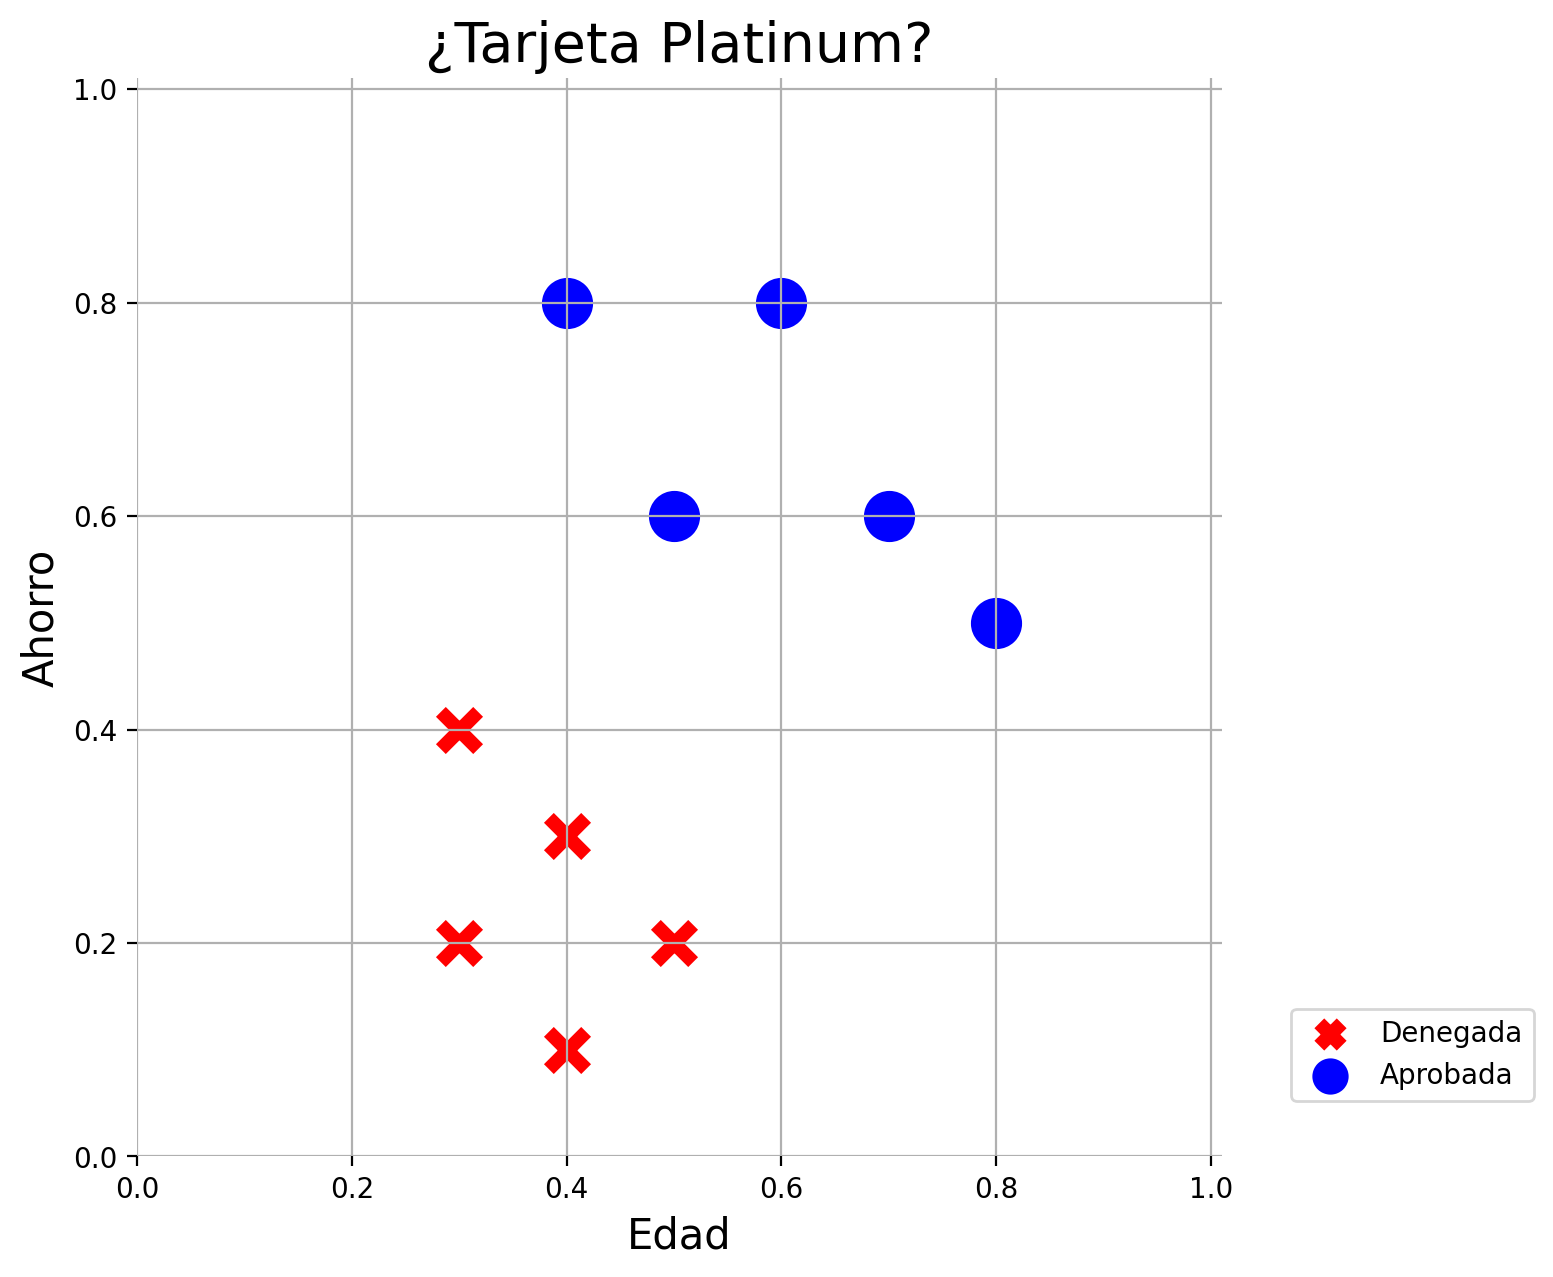

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de 10 personas -> [edad, ahorro]

personas = np.array([[0.3, 0.4], [0.4, 0.3],
                     [0.3, 0.2], [0.4, 0.1],
                     [0.5, 0.2], [0.4, 0.8],
                     [0.6, 0.8], [0.5, 0.6],
                     [0.7, 0.6], [0.8, 0.5]])

# 1 : aprobada    0 : denegada

clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Gráfica de dispersión (edad, ahorro)

plt.figure(figsize=(7, 7), dpi=200)
plt.title("¿Tarjeta Platinum?", fontsize=20)

plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")

plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")

plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15), markerscale=0.6)
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()


## 1. Función de Activación

El perceptrón utiliza una **función escalonada** (*step function*) como función de activación:

$$\hat{y} = \begin{cases} 1 & \text{si } \mathbf{w} \cdot \mathbf{x} + b > 0 \\ 0 & \text{en otro caso} \end{cases}$$

donde $\mathbf{w}$ son los pesos, $\mathbf{x}$ la entrada y $b$ el sesgo (*bias*).

Los pesos iniciales se generan aleatoriamente en el intervalo $[-1, 1]$ usando `seed=26` para que los resultados sean reproducibles. La prueba con la entrada `[0.5, 0.5]` sirve para mostrar que **antes del entrenamiento** el perceptrón clasifica incorrectamente.


In [32]:
# W1*X1 + W2*X2 + ... Wn*Xn

def activation(pesos, x, b):
    z = pesos * x
    if z.sum() + b > 0:
        return 1
    else:
        return 0

rng = np.random.default_rng(seed=26)

pesos = rng.uniform(-1, 1, size=2)
b = rng.uniform(-1, 1)

pesos, b, activation(pesos, [0.5, 0.5], b)

(array([-0.01680216, -0.53120095]), -0.8647844836153478, 0)

## Pseudocódigo del Perceptrón

0. Inicializar los pesos y el umbral
1. épocas máximas = 100
2. época = 0
3. tasa de aprendizaje = 0.01
4. Mientras (época < épocas máximas) hacer:
5. &nbsp;&nbsp;&nbsp;&nbsp;Para cada instancia de entrenamiento hacer:
6. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Calcula salida del perceptrón para esa estancia
7. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Calcula el error
8. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Actualiza pesos y umbral usando la tasa de aprendizaje, la instancia y el error
9. &nbsp;&nbsp;&nbsp;&nbsp;época += 1

## 3. Entrenamiento

Los pesos se vuelven a inicializar con la misma semilla (`seed=26`) para que el punto de partida sea idéntico al de la prueba anterior y los resultados sean comparables.

**Parámetros de entrenamiento:**
- `tasa_de_aprendizaje = 0.1` (α): controla qué tan grande es el ajuste en cada paso. Un valor muy alto puede hacer que los pesos oscilen sin converger; uno muy bajo ralentiza el aprendizaje.
- `épocas = 100`: número máximo de pasadas completas sobre el conjunto de datos.

---

### Regla de actualización de pesos

En cada ejemplo de entrenamiento se calcula el **error** como la diferencia entre la clase real y la predicción del perceptrón:

$$\text{error} = y - \hat{y}$$

Con ese error se actualizan simultáneamente los pesos y el sesgo:

$$w_j \leftarrow w_j + \alpha \cdot x_j \cdot \text{error}$$
$$b \leftarrow b + \alpha \cdot \text{error}$$

Hay exactamente tres casos posibles:

| Situación | $y$ | $\hat{y}$ | Error | Efecto en los pesos |
|---|:---:|:---:|:---:|---|
| Clasificación **correcta** | cualquiera | = $y$ | **0** | Sin cambio |
| **Falso negativo** (debía ser 1, predijo 0) | 1 | 0 | **+1** | Los pesos **aumentan** en $\alpha \cdot x_j$ |
| **Falso positivo** (debía ser 0, predijo 1) | 0 | 1 | **−1** | Los pesos **disminuyen** en $\alpha \cdot x_j$ |

**¿Por qué funciona?**  
La frontera de decisión está definida por $\mathbf{w} \cdot \mathbf{x} + b = 0$. Aumentar $w_j$ cuando hay un falso negativo mueve la frontera de modo que el punto problemático caiga del lado positivo en el siguiente paso. Disminuirlos ante un falso positivo hace lo contrario. De forma iterativa, la frontera se **gira y desplaza** hasta separar correctamente las clases.

**Convergencia:** El *Teorema de Convergencia del Perceptrón* (Rosenblatt, 1958) garantiza que, si los datos son **linealmente separables**, el algoritmo encontrará una solución en un número finito de pasos. La secuencia de errores totales `5 2 2 2 2 2 2 1 0 0 …` confirma que el perceptrón **converge en la época 7**.


In [33]:
rng = np.random.default_rng(seed=26)

pesos = rng.uniform(-1, 1, size=2)
b = rng.uniform(-1, 1)
tasa_de_aprendizaje = 0.1
épocas = 100

for época in range(épocas):
    error_total = 0
    for i in range(len(personas)):
        prediction = activation(pesos, personas[i], b)
        error = clases[i] - prediction
        error_total += error**2
        pesos[0] += tasa_de_aprendizaje * personas[i][0] * error
        pesos[1] += tasa_de_aprendizaje * personas[i][1] * error
        b += tasa_de_aprendizaje * error
    print(error_total, end=" ")

activation(pesos, [0.1, 0], b)

5 2 2 2 2 2 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

0

## 4. Frontera de Decisión

La **frontera de decisión** es la línea (o hiperplano, en dimensiones superiores) que separa las dos clases en el espacio de características. Para el perceptrón con dos entradas queda definida implícitamente por:

$$w_1 \cdot \text{edad} + w_2 \cdot \text{ahorro} + b = 0$$

La visualización evalúa `activation()` en una grilla densa de puntos del plano [0,1]×[0,1] y colorea cada punto según la clase predicha, permitiendo ver las regiones de decisión aprendidas.


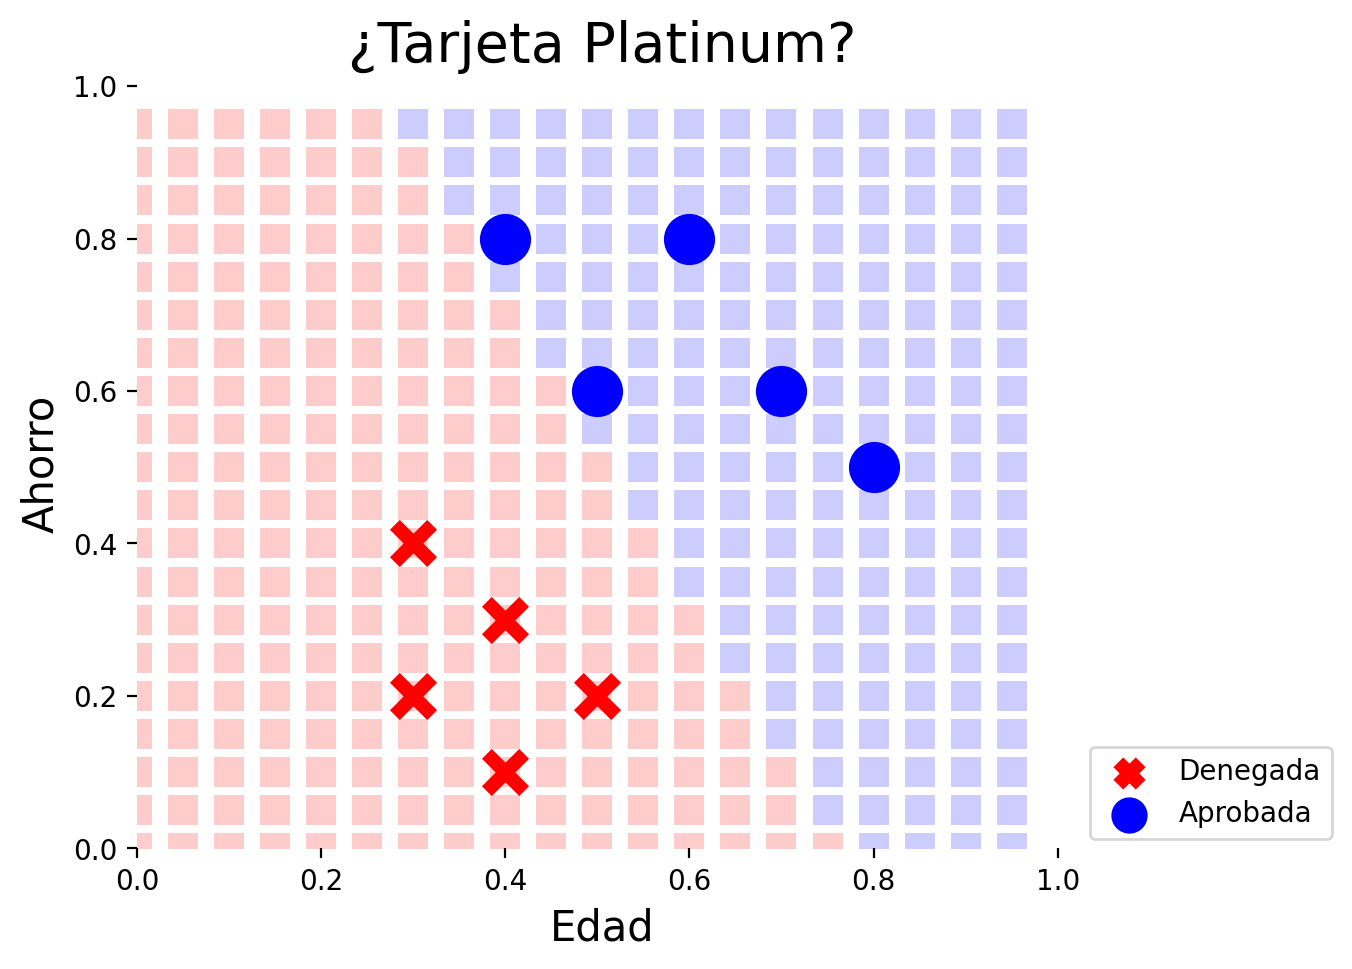

In [34]:
plt.figure(figsize=(6, 5), dpi=200)
plt.title("¿Tarjeta Platinum?", fontsize=20)

plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")

plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")

for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        color = activation(pesos, [edad, ahorro], b)
        if color == 1:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="blue", alpha=0.2, linewidths=0)
        else:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="red", alpha=0.2, linewidths=0)

plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15), markerscale=0.6)
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()


## 5. Comparación con Scikit-learn

Para validar que la implementación manual es correcta se entrena el perceptrón incluido en `scikit-learn` con los mismos datos. Se usa `random_state=26` para que los pesos iniciales sean equivalentes.

Si ambas implementaciones producen las mismas predicciones sobre los puntos de prueba `[0.2, 0.2]` y `[0.8, 0.8]`, la implementación manual queda verificada.


In [35]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron(random_state=26).fit(personas, clases)
perceptron.predict([[0.2, 0.2], [0.8, 0.8]])

array([0, 1])

## Referencias

Codigo Maquina. (s.f.). *Perceptrón Paso a Paso con Python: La Base de las Redes Neuronales Artificiales de Machine Learning* [Video]. YouTube. [https://www.youtube.com/watch?v=dkhXGTersP0](https://www.youtube.com/watch?v=dkhXGTersP0)

Hernández Parada, M. S. (2025). *Maestría en Inteligencia Artificial — Prácticas* [Repositorio de GitHub]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%201.2/An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20del%20algoritmo%20del%20perceptr%C3%B3n%20de%20Frank%20Rosenblatt.ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%201.2/An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20del%20algoritmo%20del%20perceptr%C3%B3n%20de%20Frank%20Rosenblatt.ipynb)
